In [53]:
import tensorflow as tf
from tensorflow import keras

print(tf.__version__)

print(keras.__version__)

2.3.0
2.4.0


In [54]:
fashion_mnist = keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [55]:
print(train_images.shape) # 28x28 사이즈의 이미지를 6만장 가지고있다.
print(train_images)

(60000, 28, 28)
[[[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 ...

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]]


In [56]:
print(train_labels.shape) #6만개의 정답을 가지고 있다. 첫번째 이미지에 대한 답은 9
print(train_labels)

(60000,)
[9 0 0 ... 3 0 5]


0


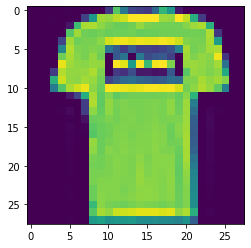

In [78]:
import matplotlib.pyplot as plt
plt.imshow(train_images[1])
print(train_labels[1])

In [79]:
# model = keras.Sequential([
#                         keras.layers.Flatten(input_shape=(28,28)), #1차원으로 바꿔줌 
#                         keras.layers.Dense(128, activation=tf.nn.relu), #if (x>0) return x: else return 0
#                         keras.layers.Dense(10, activation=tf.nn.softmax) #출력된 레이블들의 전체의 합이 1이되도록 스케일을 낮춰줌
# ])

In [80]:
# model.compile(optimizer='adam',
#               loss='sqarse_categorical')

In [81]:
model = keras.Sequential([
                        keras.layers.Flatten(input_shape=(28,28)), #1차원으로 바꿔줌 
                        keras.layers.Dense(units=128, activation=tf.nn.relu), #if (x>0) return x: else return 0
                        keras.layers.Dense(units=10, activation=tf.nn.softmax) #출력된 레이블들의 전체의 합이 1이되도록 스케일을 낮춰줌
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy')

In [82]:
model.fit(train_images, train_labels, epochs = 5)

Epoch 1/5
1875/1875 [==============================] - 3s 2ms/step - loss: 2.6111
Epoch 2/5
1875/1875 [==============================] - 3s 2ms/step - loss: 0.6934
Epoch 3/5
1875/1875 [==============================] - 3s 2ms/step - loss: 0.6135
Epoch 4/5
1875/1875 [==============================] - 3s 2ms/step - loss: 0.5546
Epoch 5/5
1875/1875 [==============================] - 3s 2ms/step - loss: 0.5204


In [83]:
import numpy as np

In [84]:
print(np.array([test_images[0]]).shape)

(1, 28, 28)


In [85]:
print((model.predict(np.array([test_images[0]]))*100).astype(np.int))

[[ 0  0  0  0  0  1  0  7  0 91]]


In [86]:
print(model. get_weights())
print(model.predict(np.array([test_images[0]]))) #새로운 입력에 대해서 학습결과

[array([[ 0.02243875,  0.03848209,  0.03999137, ...,  0.07239977,
         0.18592766, -0.05483172],
       [-0.01554317, -0.03720528,  0.0426361 , ..., -0.05995521,
        -0.09091609,  0.0777323 ],
       [-0.03243792,  0.01433799, -0.03945177, ..., -0.03502841,
        -0.20880929,  0.00638027],
       ...,
       [ 0.0797331 , -0.04500398, -0.00245452, ...,  0.06333471,
        -0.06231622, -0.07848592],
       [ 0.14962739, -0.03458684, -0.06846684, ...,  0.00132156,
        -0.08039647, -0.05980607],
       [ 0.09837953, -0.07537217,  0.00156727, ...,  0.04985804,
        -0.13683505,  0.07320649]], dtype=float32), array([-0.29355666, -0.0202427 , -0.02713257, -0.04727798, -0.01857831,
        0.00649251, -0.05280136,  0.00158886, -0.0242416 , -0.02812475,
       -0.01141295, -0.02315489, -0.04744242, -0.01790139, -0.01764853,
       -0.01364255, -0.02249079, -0.01104966,  0.00235003, -0.00975989,
       -0.01651119, -0.04454907, -0.01134895,  0.00266918,  0.11845774,
       -0.

In [87]:
print(test_labels[0])

9


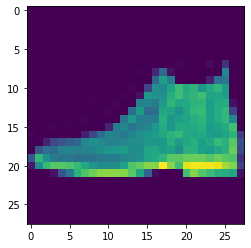

In [89]:
plt.imshow(test_images[0])

In [90]:
model.evaluate(test_images, test_labels) 

313/313 [==============================] - 0s 1ms/step - loss: 0.5827


0.5826600193977356